# MNIST Digit Classifier

A simple feedforward neural network trained on the [MNIST](http://yann.lecun.com/exdb/mnist/) dataset to classify handwritten digits (0–9).

**Architecture:** 784 → 128 → 64 → 10 (fully connected layers with ReLU activations)


In [53]:
import ssl

import onnx
import torch
import torchviz
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


# Data Loading


In [54]:
# macOS Python doesn't use the system keychain for SSL by default,
# so we patch the default context to allow downloading torchvision datasets.
ssl._create_default_https_context = ssl._create_unverified_context

# define a transform to normalize the data
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),  # MNIST mean and std
    ]
)

train_dataset = datasets.MNIST(
    root="./data", train=True, transform=transform, download=True
)
test_dataset = datasets.MNIST(
    root="./data", train=False, transform=transform, download=True
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")
print(f"Input shape:   {train_dataset[0][0].shape}")
print(f"Classes:       {train_dataset.classes}")

Train samples: 60000
Test samples:  10000
Input shape:   torch.Size([1, 28, 28])
Classes:       ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


# Model Architecture


In [55]:
flattened_input_size = 28 * 28
hidden_size_1 = 128
hidden_size_2 = 64
num_classes = 10

model = torch.nn.Sequential(
    torch.nn.Linear(flattened_input_size, hidden_size_1),
    torch.nn.ReLU(),
    torch.nn.Linear(hidden_size_1, hidden_size_2),
    torch.nn.ReLU(),
    torch.nn.Linear(hidden_size_2, num_classes),
)
# Move the model to the available device (CPU or GPU)
model.to(device)

print(model)

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
)


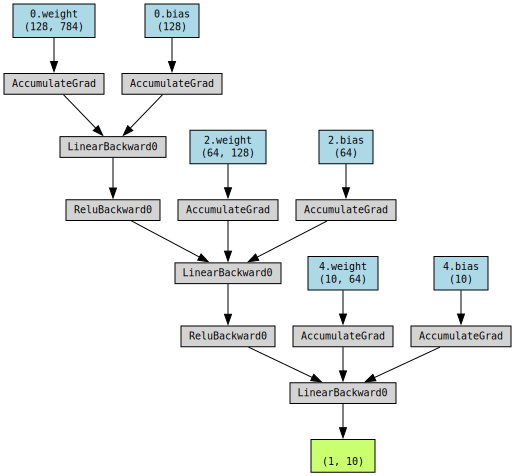

In [56]:
# Visualize the model's computation graph using a dummy input
dummy_input = torch.randn(1, flattened_input_size).to(device)
torchviz.make_dot(model(dummy_input), params=dict(model.named_parameters()))

# Training


In [57]:
# CrossEntropyLoss combines LogSoftmax and NLLLoss, which is more
# numerically stable than Softmax + NLLLoss applied separately.
criterion = torch.nn.CrossEntropyLoss()

# Adam adapts the learning rate per parameter, typically converging
# faster than vanilla stochastic gradient descent.
learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

num_epochs = 5
for epoch in range(num_epochs):
    # Training mode is important for layers like dropout and batch normalization
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        images = images.view(-1, flattened_input_size)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch + 1}/{num_epochs}], Avg Loss: {avg_loss:.4f}")

Epoch [1/5], Avg Loss: 0.2738
Epoch [2/5], Avg Loss: 0.1142
Epoch [3/5], Avg Loss: 0.0803
Epoch [4/5], Avg Loss: 0.0611
Epoch [5/5], Avg Loss: 0.0512


# Evaluation


In [58]:
model.eval()
with torch.no_grad():
    correct, total = 0, 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        images = images.view(-1, flattened_input_size)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 97.02%


# Model Export


In [ ]:
torch.save(model.state_dict(), "./data/output/mnist/model.pth")
print("Model weights saved to ./data/output/mnist/model.pth")

Model weights saved to ./data/mnist/model.pth


In [ ]:
example_inputs = torch.randn(1, flattened_input_size).to(device)
onnx_program = torch.onnx.export(model, example_inputs, dynamo=True)

onnx_program.save("./data/output/mnist/image_classifier_model.onnx")

onnx_model = onnx.load("./data/output/mnist/image_classifier_model.onnx")
onnx.checker.check_model(onnx_model)
print("ONNX model validated successfully.")

W0225 08:58:13.557000 88547 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0225 08:58:13.557000 88547 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0225 08:58:13.558000 88547 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0225 08:58:13.559000 88547 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX model validated successfully.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
